In [156]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [157]:
data= r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Data_model_payment.csv"
df= pd.read_csv(data)
#print(df.head(1))
print(df.columns)

Index(['transaction_id', 'parent_transaction_id', 'merchant_transaction_id',
       'checkout_id', 'user_account_id', 'transaction_source', 'merchant_id',
       'sub_merchant_id', 'fraud_recommendation', 'payment_instrument',
       'emi_tenure', 'transaction_time', 'original_amount', 'you_pay_amount',
       'effective_pay_amount', 'emi_type', 'emi_installment_value',
       'total_interest', 'total_cost', 'interest_value', 'transaction_status',
       'transaction_funnel_step', 'response_code', 'response_message',
       'auth_state', 'visit_id', 'read_sms', 'phonepe_sdk', 'juspay_sdk',
       'bank_code', 'masked_instrument_number', 'card_type', 'country_type',
       'instrument_hash_id', 'expiry_month', 'expiry_year', 'instrument_type',
       'card_country', 'card_bin', 'card_network', 'instrument_id',
       'instrument_saved_state', 'pg_id', 'pg_mid', 'pg_track_id', 'pg_txn_id',
       'enrolled_type', 'routing_id', 'auth_mode', 'reference_id1',
       'reference_id2', 'rrn', 

In [158]:
print(df.dtypes.unique())

[dtype('O') dtype('int64') dtype('bool') dtype('float64')]


In [159]:
#print(df.select_dtypes(include=["bool"]))

In [160]:
#print(df.isnull().sum())
#print(df.isnull().sum()[df.isnull().sum() >0])

datetime64[ns]
txn_hour     int32
txn_month    int32
txn_day      int32
dtype: object
['REJECT' 'UNKNOWN' 'ACCEPT' 'REVIEW']
Numeric Columns ['original_amount', 'you_pay_amount', 'emi_tenure', 'pay_ratio', 'effective_pay_amount']
Categorical_columns ['payment_instrument', 'card_type', 'transaction_status', 'response_code', 'auth_mode', 'biometric_executed', 'fallback_request']
              precision    recall  f1-score   support

      ACCEPT       0.99      0.91      0.95    138376
      REJECT       1.00      1.00      1.00       817
      REVIEW       0.19      0.68      0.29      4129
     UNKNOWN       1.00      1.00      1.00     96678

    accuracy                           0.94    240000
   macro avg       0.79      0.90      0.81    240000
weighted avg       0.98      0.94      0.96    240000



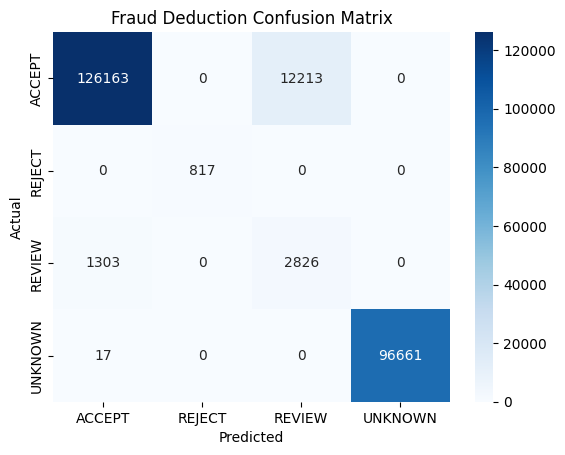

In [161]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

df = df.dropna(subset=['transaction_id', 'user_account_id', 'original_amount'])
df['emi_tenure'] = df['emi_tenure'].fillna(0)
df = df.drop_duplicates(subset=['transaction_id'])

df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce')
print(df['transaction_time'].dtypes)
df['txn_hour'] = df['transaction_time'].dt.hour
df['txn_month'] = df['transaction_time'].dt.month
df['txn_day'] =df['transaction_time'].dt.day

print(df[['txn_hour','txn_month', 'txn_day']].dtypes)
import numpy as np
#df['pay_ratio'] = df['you_pay_amount'] /df['original_amount']
df['pay_ratio'] = np.where(df['original_amount']==0,0, df['you_pay_amount']/df['original_amount'])
df['card_type'] = df['card_type'].fillna('unknown')
df['fraud_recommendation'] = df['fraud_recommendation'].fillna('UNKNOWN')
df['response_code'] = df['response_code'].fillna('SUCCESS')
df['auth_mode'] = df['auth_mode'].fillna('unknown')
df['biometric_executed'] = df['biometric_executed'].fillna(False).astype(str)
df['effective_pay_amount'] = df['effective_pay_amount'].fillna(df['you_pay_amount'])
print(df['fraud_recommendation'].unique())

y= df['fraud_recommendation']
#y = y.fillna('unknown')
X = df[[
    # Original Features
    'original_amount', 'you_pay_amount', 'emi_tenure', 
    'txn_hour', 'txn_day', 'txn_month', 'pay_ratio', 
    'payment_instrument', 'card_type', 'transaction_status',
    # Brand New Strategic Features
    'effective_pay_amount', 'response_code', 'auth_mode', 
    'biometric_executed', 'fallback_request'
]]

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',classes= classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(class_weight_dict)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','bool','category']).columns.tolist()
print("Numeric Columns", numeric_features)
print("Categorical_columns",categorical_features) 

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical_features)
    ])

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state= 42))
])

class_weight_dict = {
    'ACCEPT': 1.0,
    'UNKNOWN': 1.0,
    'REJECT': 50.0,
    'REVIEW': 15.0
}
sample_weights = y_train.map(class_weight_dict)

clf.fit(X_train, y_train, model__sample_weight=sample_weights)
y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred, labels=clf.classes_)
sns.heatmap(cm,annot= True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Deduction Confusion Matrix")
plt.show()

In [162]:
print(y.isnull().sum())
print(X.isnull().sum())
#print(df['card_type'].dtypes)
#print(df['card_type'].unique())

0
original_amount         0
you_pay_amount          0
emi_tenure              0
txn_hour                0
txn_day                 0
txn_month               0
pay_ratio               0
payment_instrument      0
card_type               0
transaction_status      0
effective_pay_amount    0
response_code           0
auth_mode               0
biometric_executed      0
fallback_request        0
dtype: int64


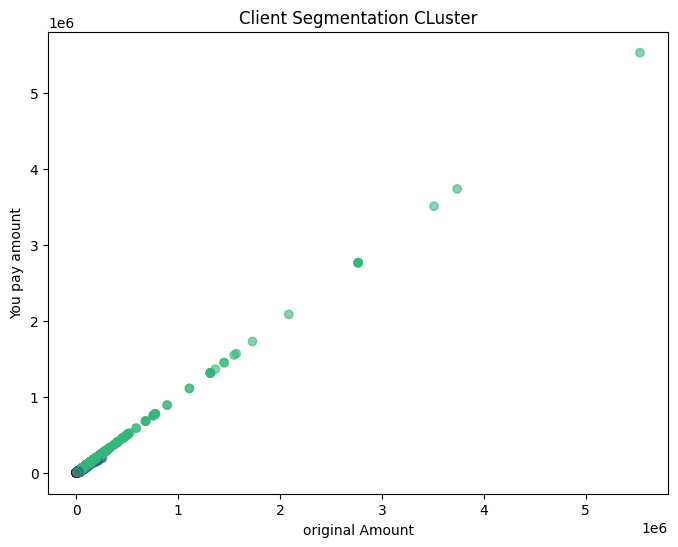

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df['log_original_amount'] = np.log1p(df['original_amount'])
df['log_you_pay_amount'] = np.log1p(df['you_pay_amount'])

cluster_features = ['log_original_amount', 'log_you_pay_amount', 'pay_ratio']
scaler_km = StandardScaler()
scaled_clusted_data = scaler_km.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
#df['cluster'] =kmeans.fit_predict(df[['original_amount','you_pay_amount']])
df['client_cluster'] =kmeans.fit_predict(scaled_clusted_data)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df['original_amount'],
    df['you_pay_amount'],
    c=df['client_cluster'],
    cmap= 'viridis',
    alpha = 0.6)
plt.xlabel("original Amount")
plt.ylabel("You pay amount")
plt.title("Client Segmentation CLuster")
plt.show()


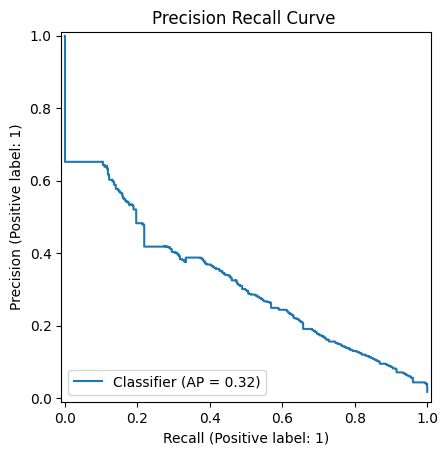

In [164]:
from sklearn.metrics import PrecisionRecallDisplay
y_prob_review = clf.predict_proba(X_test)[:,2]
y_test_review = (y_test == 'REVIEW').astype(int)

PrecisionRecallDisplay.from_predictions(y_test_review, y_prob_review)
plt.title("Precision Recall Curve ")
plt.show()

In [165]:
export_df = X_test.assign(Actual= y_test, Predicted = y_pred)
export_df['transaction_id'] =df.loc[X_test.index, 'transaction_id']
review_only_df = export_df[export_df['Predicted'] =='REVIEW']
output= r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Out_put_fraud_dection.xlsx"
review_only_df.to_excel(output, index=False, engine='openpyxl')